# Time Series Breakdown of Retail Sales 🛒🛍️✨

## 1️⃣ Required Libraries

In [1]:
import pandas as pd 
import numpy as np 
from matplotlib import pyplot as plt 
import seaborn as sns 

## 2️⃣ Read the Dataset 

In [2]:
path = r'Dataset\Walmart.csv'
df = pd.read_csv(path)

In [3]:
df.shape

(6435, 8)

In [4]:
df.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106


## 3️⃣ Exploratory Data Analysis (EDA)

### Information

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         6435 non-null   int64  
 1   Date          6435 non-null   object 
 2   Weekly_Sales  6435 non-null   float64
 3   Holiday_Flag  6435 non-null   int64  
 4   Temperature   6435 non-null   float64
 5   Fuel_Price    6435 non-null   float64
 6   CPI           6435 non-null   float64
 7   Unemployment  6435 non-null   float64
dtypes: float64(5), int64(2), object(1)
memory usage: 402.3+ KB


### Description

In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Store,6435.0,2.300000e+01,12.988182,1.000,12.000,23.000000,3.400000e+01,4.500000e+01
Weekly_Sales,6435.0,1.046965e+06,564366.622054,209986.250,553350.105,960746.040000,1.420159e+06,3.818686e+06
Holiday_Flag,6435.0,6.993007e-02,0.255049,0.000,0.000,0.000000,0.000000e+00,1.000000e+00
Temperature,6435.0,6.066378e+01,18.444933,-2.060,47.460,62.670000,7.494000e+01,1.001400e+02
Fuel_Price,6435.0,3.358607e+00,0.459020,2.472,2.933,3.445000,3.735000e+00,4.468000e+00
CPI,6435.0,1.715784e+02,39.356712,126.064,131.735,182.616521,2.127433e+02,2.272328e+02
Unemployment,6435.0,7.999151e+00,1.875885,3.879,6.891,7.874000,8.622000e+00,1.431300e+01


### Check Columns

In [8]:
df.columns

Index(['Store', 'Date', 'Weekly_Sales', 'Holiday_Flag', 'Temperature',
       'Fuel_Price', 'CPI', 'Unemployment'],
      dtype='object')

#### Fix Date Column

In [9]:
df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y')

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Store         6435 non-null   int64         
 1   Date          6435 non-null   datetime64[ns]
 2   Weekly_Sales  6435 non-null   float64       
 3   Holiday_Flag  6435 non-null   int64         
 4   Temperature   6435 non-null   float64       
 5   Fuel_Price    6435 non-null   float64       
 6   CPI           6435 non-null   float64       
 7   Unemployment  6435 non-null   float64       
dtypes: datetime64[ns](1), float64(5), int64(2)
memory usage: 402.3 KB


### Check Missing Values

In [15]:
df.isna().sum()

Store           0
Date            0
Weekly_Sales    0
Holiday_Flag    0
Temperature     0
Fuel_Price      0
CPI             0
Unemployment    0
dtype: int64

### Check Duplications

In [16]:
df.duplicated().sum()

0

### Numeric Columns

In [ ]:
num_col = df.select_dtypes(['float64', 'int64']).columns
num_col[1:]

Index(['Weekly_Sales', 'Holiday_Flag', 'Temperature', 'Fuel_Price', 'CPI',
       'Unemployment'],
      dtype='object')

#### Hist + KDE

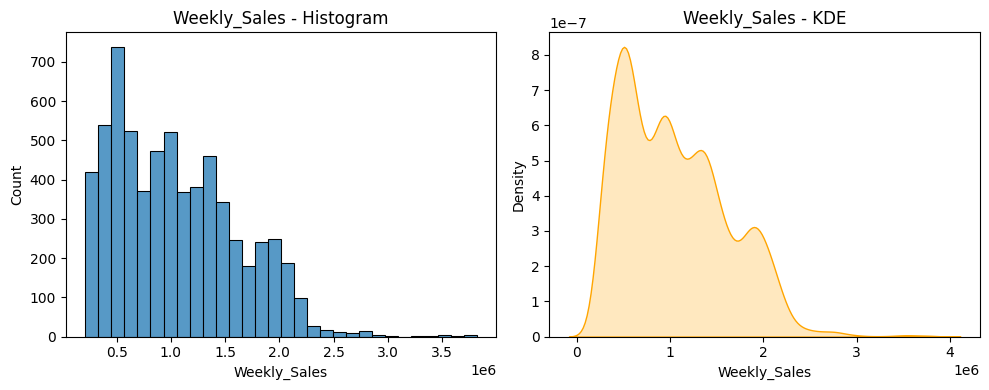

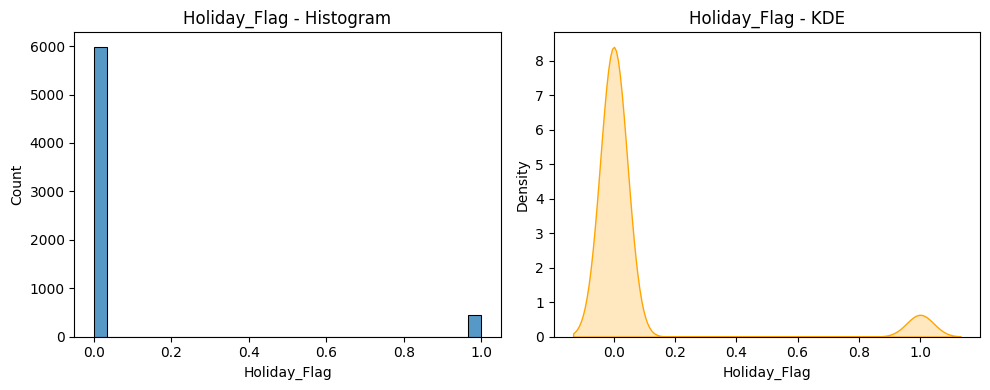

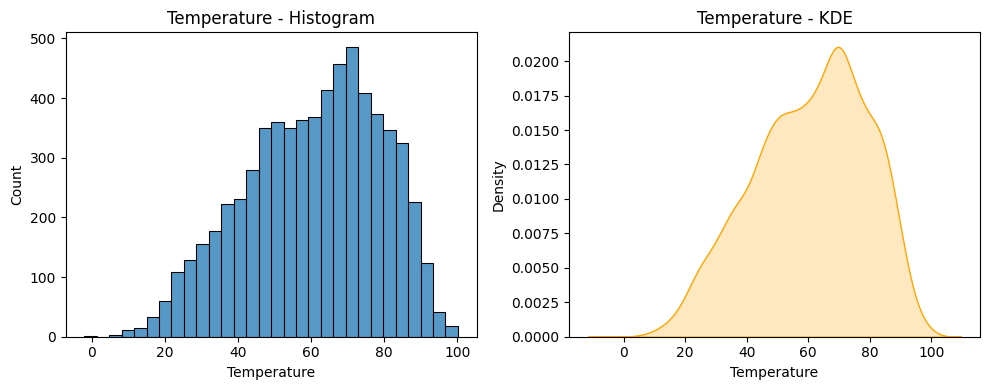

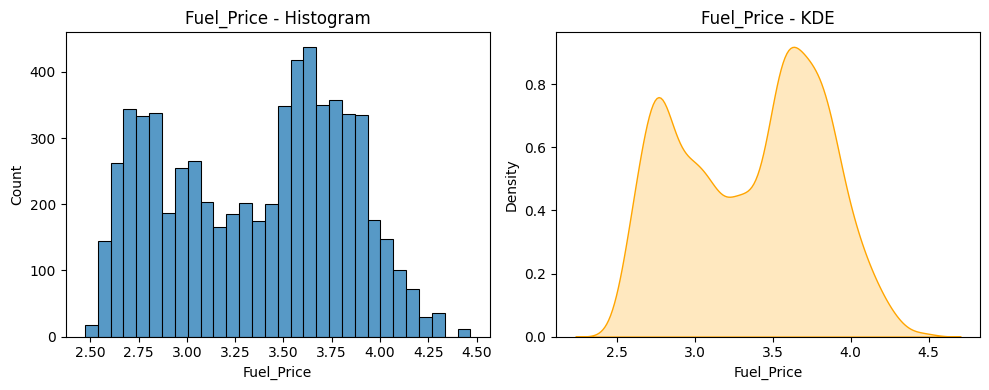

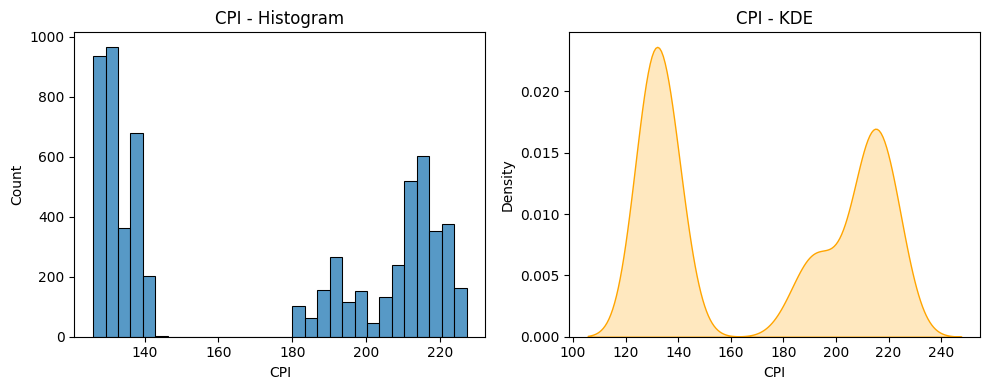

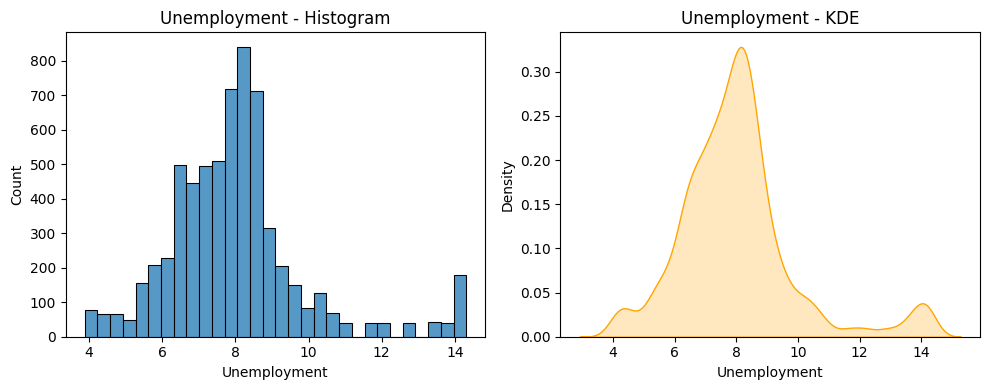

In [101]:
for col in num_col[1:]:
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    # Histogram
    sns.histplot(df[col], bins=30, ax=axes[0])
    axes[0].set_title(f'{col} - Histogram')

    # KDE
    sns.kdeplot(df[col], fill=True, ax=axes[1], color='orange')
    axes[1].set_title(f'{col} - KDE')

    plt.tight_layout()
    plt.show()


#### Boxplot + Violinplot

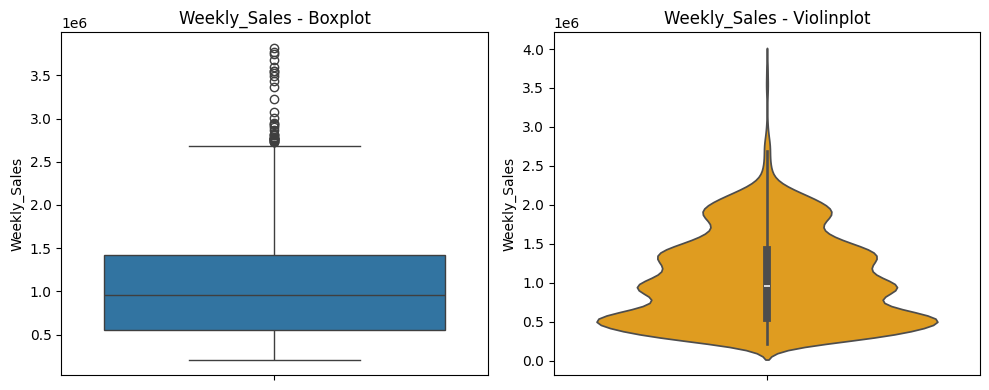

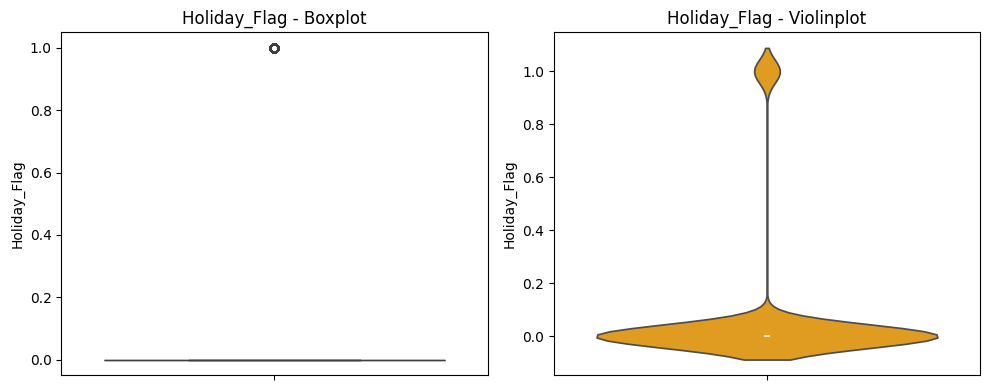

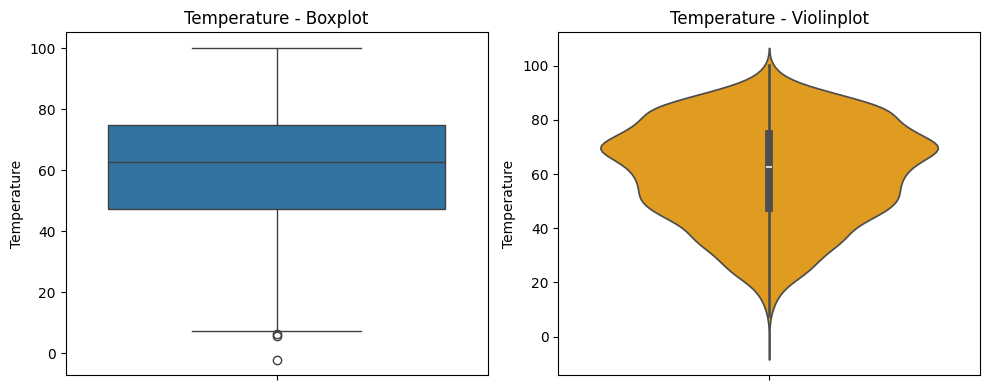

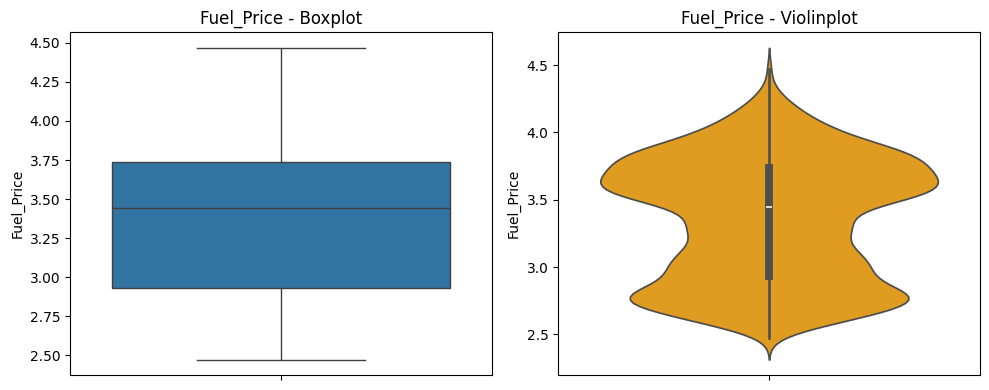

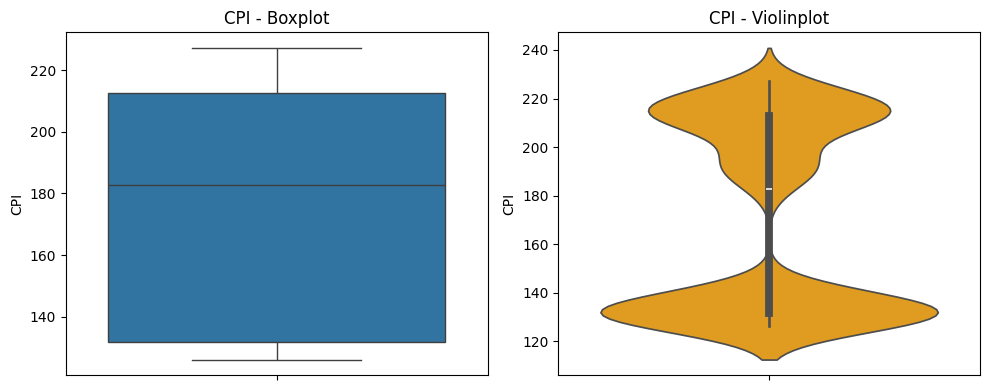

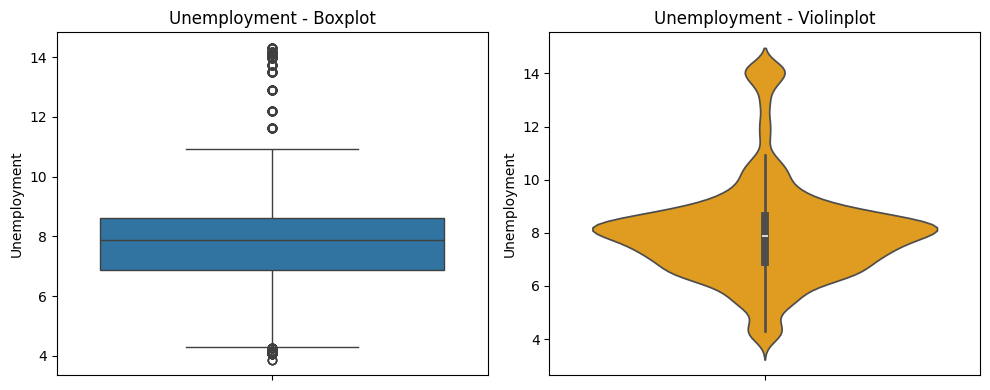

In [102]:
for col in num_col[1:]:
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    # Boxplot
    sns.boxplot(df[col], ax=axes[0])
    axes[0].set_title(f'{col} - Boxplot')

    # Violinplot
    sns.violinplot(df[col], fill=True, ax=axes[1], color='orange')
    axes[1].set_title(f'{col} - Violinplot')

    plt.tight_layout()
    plt.show()


#### Correlation Matrix

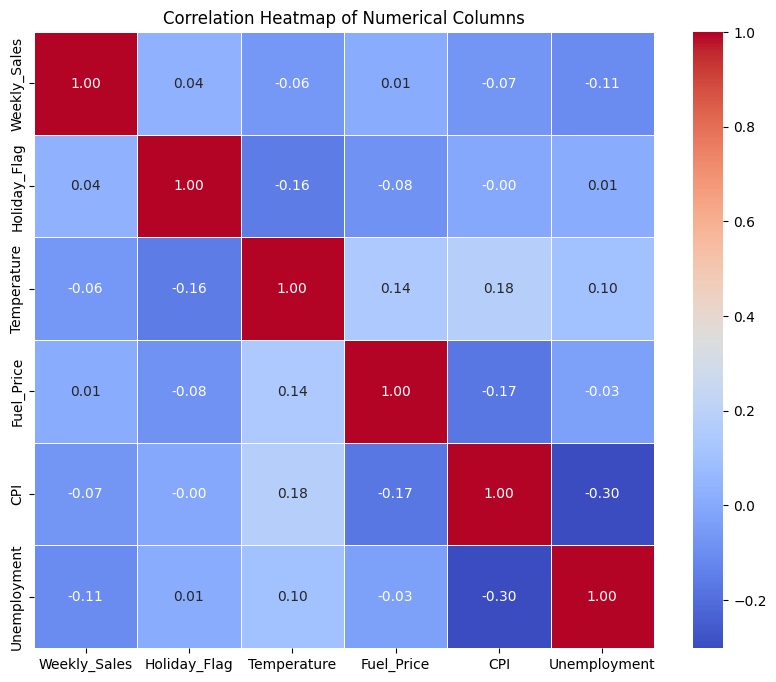

In [103]:
corr_matrix = df[num_col[1:]].corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title('Correlation Heatmap of Numerical Columns')
plt.show()


### Aanlysis

#### Check Range of Date

In [13]:
df['Date'].dt.date.min()

datetime.date(2010, 2, 5)

In [14]:
df['Date'].dt.date.max()

datetime.date(2012, 10, 26)

#### Check Weekly Sales Trend Over Time

In [26]:
daily_sales = df.groupby('Date')['Weekly_Sales'].sum().reset_index()

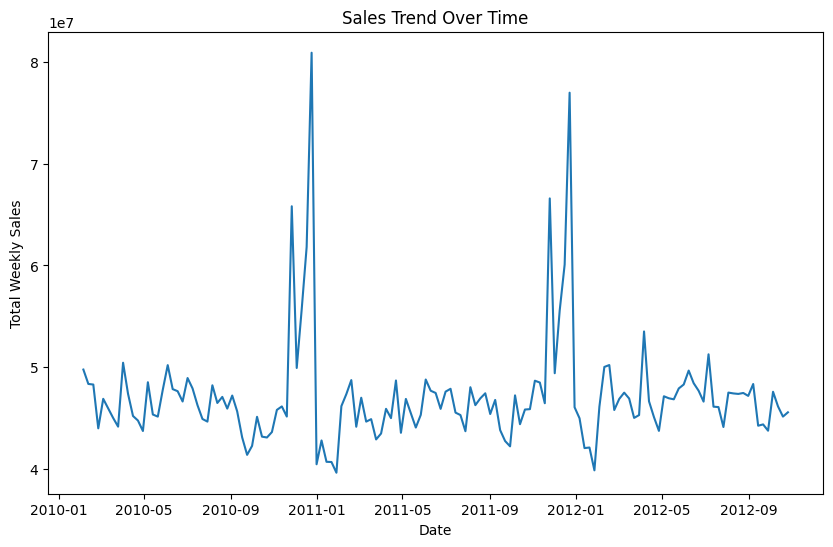

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(daily_sales['Date'], daily_sales['Weekly_Sales'])
plt.xlabel('Date')
plt.ylabel('Total Weekly Sales')
plt.title('Sales Trend Over Time')
plt.grid(True)
plt.tight_layout()
plt.show()

#### Check Number of Stores

In [37]:
df['Store'].value_counts().keys().max()

45

#### Check CPI rate

In [38]:
cpi = df.groupby('Date')['CPI'].sum().reset_index()

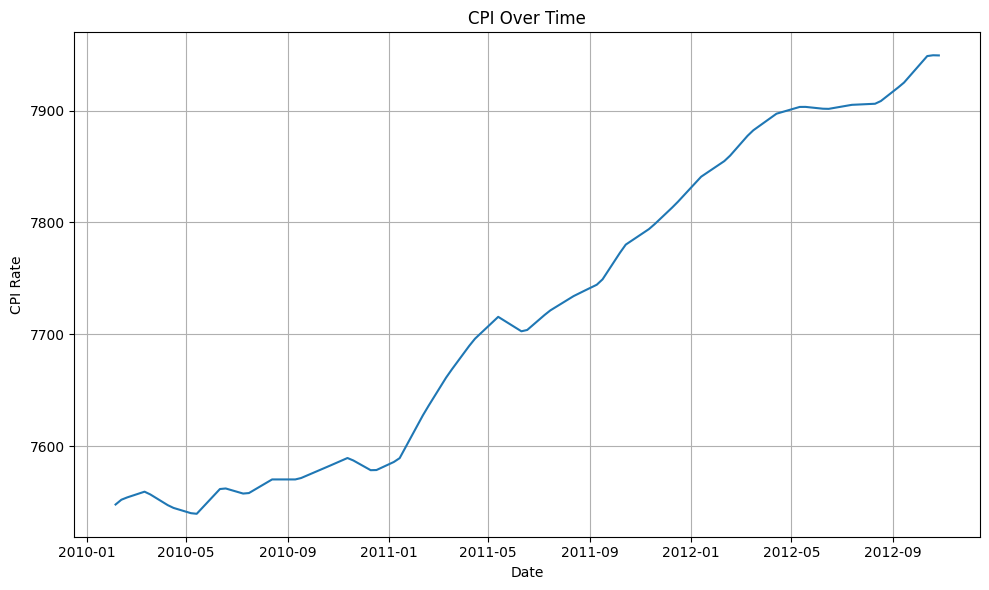

In [59]:
plt.figure(figsize=(10, 6))
plt.plot(cpi['Date'], cpi['CPI'])
plt.xlabel('Date')
plt.ylabel('CPI Rate')
plt.title('CPI Over Time')
plt.grid(True)
plt.tight_layout()
plt.show()

#### Check Unemployment rate

In [41]:
unemployment_rate = df.groupby('Date')['Unemployment'].sum().reset_index()

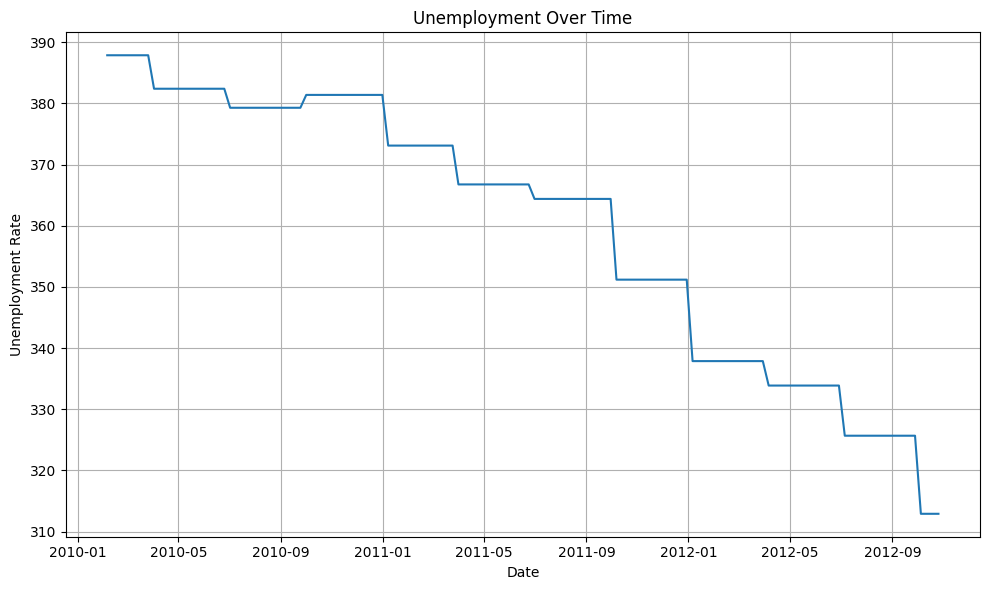

In [58]:
plt.figure(figsize=(10, 6))
plt.plot(unemployment_rate['Date'], unemployment_rate['Unemployment'])
plt.xlabel('Date')
plt.ylabel('Unemployment Rate')
plt.title('Unemployment Over Time')
plt.grid(True)
plt.tight_layout()
plt.show()

In [45]:
df.columns

Index(['Store', 'Date', 'Weekly_Sales', 'Holiday_Flag', 'Temperature',
       'Fuel_Price', 'CPI', 'Unemployment'],
      dtype='object')

#### Check Holidays Sales and Non-holidays Sales

In [ ]:
holiday_sales = df[df['Holiday_Flag']==1].groupby('Date')['Weekly_Sales'].sum()
holiday_sales

Date
2010-02-12    48336677.63
2010-09-10    45634397.84
2010-11-26    65821003.24
2010-12-31    40432519.00
2011-02-11    47336192.79
Name: Weekly_Sales, dtype: float64

In [61]:
non_holiday_sales = df[df['Holiday_Flag']==0].groupby('Date')['Weekly_Sales'].sum()
non_holiday_sales

Date
2010-02-05    49750740.50
2010-02-19    48276993.78
2010-02-26    43968571.13
2010-03-05    46871470.30
2010-03-12    45925396.51
                 ...     
2012-09-28    43734899.40
2012-10-05    47566639.31
2012-10-12    46128514.25
2012-10-19    45122410.57
2012-10-26    45544116.29
Name: Weekly_Sales, Length: 133, dtype: float64

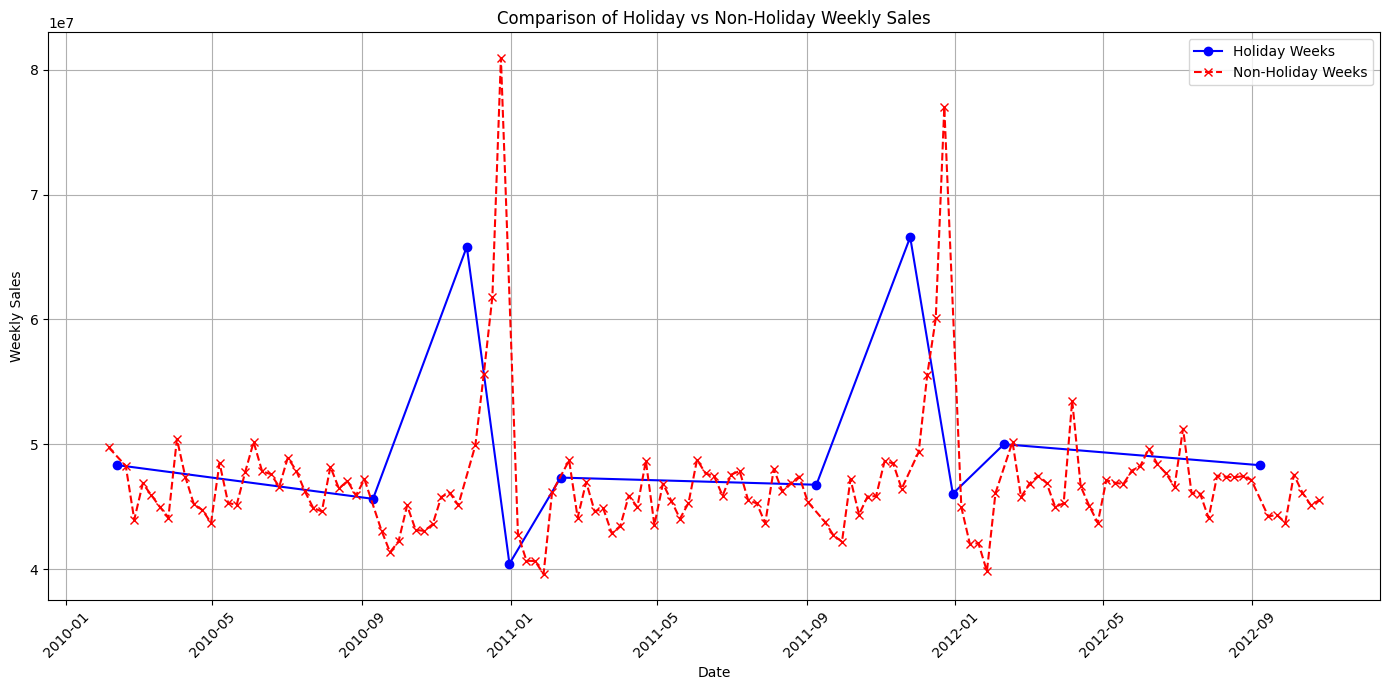

In [67]:
plt.figure(figsize=(14,7))
plt.plot(holiday_sales.index, holiday_sales.values, marker='o', linestyle='-', color='blue', label='Holiday Weeks')
plt.plot(non_holiday_sales.index, non_holiday_sales.values, marker='x', linestyle='--', color='red', label='Non-Holiday Weeks')

plt.xlabel('Date')
plt.ylabel('Weekly Sales')
plt.title('Comparison of Holiday vs Non-Holiday Weekly Sales')
plt.legend()
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()


#### Check Best Stores

In [70]:
stores_sales = df.groupby('Store')['Weekly_Sales'].sum()
stores_sales.head(10)

Store
1     2.224028e+08
2     2.753824e+08
3     5.758674e+07
4     2.995440e+08
5     4.547569e+07
6     2.237561e+08
7     8.159828e+07
8     1.299512e+08
9     7.778922e+07
10    2.716177e+08
Name: Weekly_Sales, dtype: float64

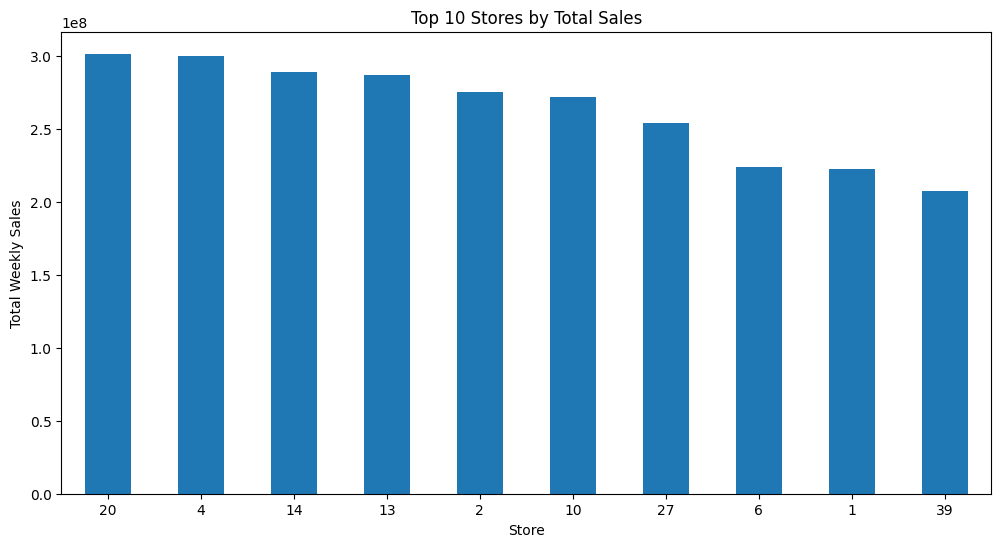

In [72]:
top_stores = stores_sales.sort_values(ascending=False).head(10)

plt.figure(figsize=(12,6))
top_stores.plot(kind='bar')
plt.xlabel('Store')
plt.ylabel('Total Weekly Sales')
plt.title('Top 10 Stores by Total Sales')
plt.xticks(rotation=0)
plt.show()

#### Check relationship Between Sales and Fuel

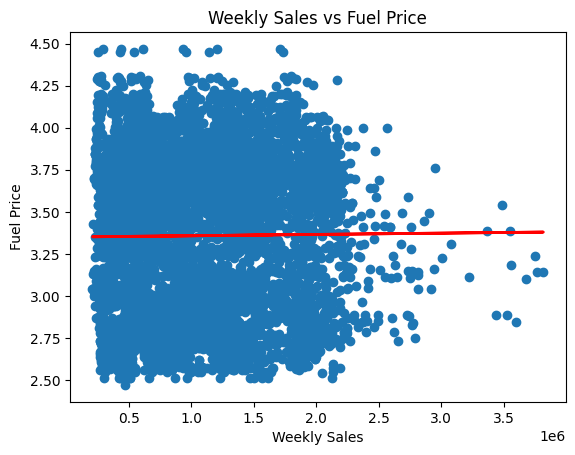

In [77]:
plt.scatter(df['Weekly_Sales'], df['Fuel_Price'])

z = np.polyfit(df['Weekly_Sales'], df['Fuel_Price'], 1)
p = np.poly1d(z)
plt.plot(df['Weekly_Sales'], p(df['Weekly_Sales']), color='red', linewidth=2)

plt.xlabel('Weekly Sales')
plt.ylabel('Fuel Price')
plt.title('Weekly Sales vs Fuel Price')
plt.show()

#### Check relationship Between Sales and Temperature

<function matplotlib.pyplot.show(close=None, block=None)>

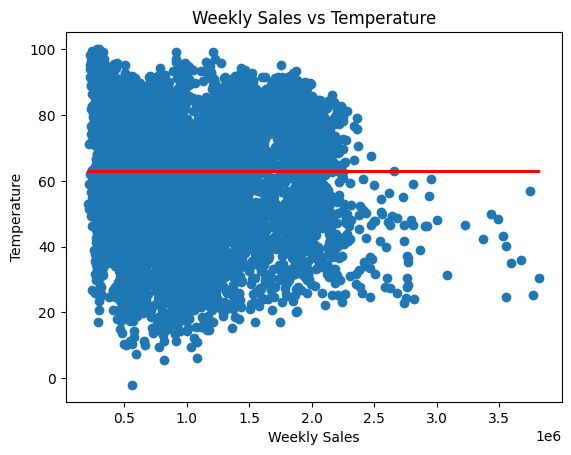

In [78]:
plt.scatter(df['Weekly_Sales'], df['Temperature'])

z = np.polyfit(df['Weekly_Sales'], df['Temperature'], 1)
p = np.poly1d(z)
plt.plot(df['Weekly_Sales'], p(df['Temperature']), color='red', linewidth=2)

plt.xlabel('Weekly Sales')
plt.ylabel('Temperature')
plt.title('Weekly Sales vs Temperature')
plt.show

#### Check relationship Between Sales and Unemployment

<function matplotlib.pyplot.show(close=None, block=None)>

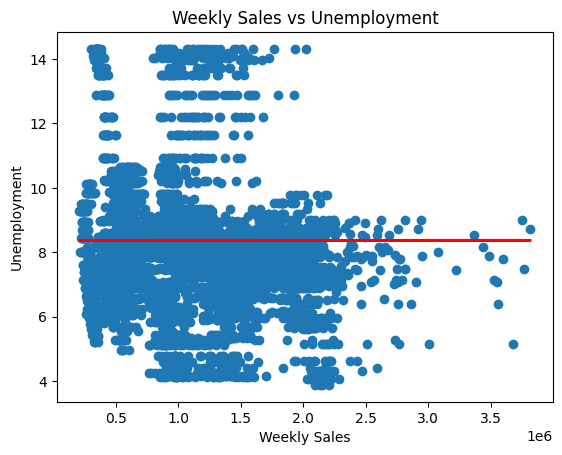

In [82]:
plt.scatter(df['Weekly_Sales'], df['Unemployment'])

z = np.polyfit(df['Weekly_Sales'], df['Unemployment'], 1)
p = np.poly1d(z)
plt.plot(df['Weekly_Sales'], p(df['Unemployment']), color='red', linewidth=2)

plt.xlabel('Weekly Sales')
plt.ylabel('Unemployment')
plt.title('Weekly Sales vs Unemployment')
plt.show

#### Average Weekly Sales by Month

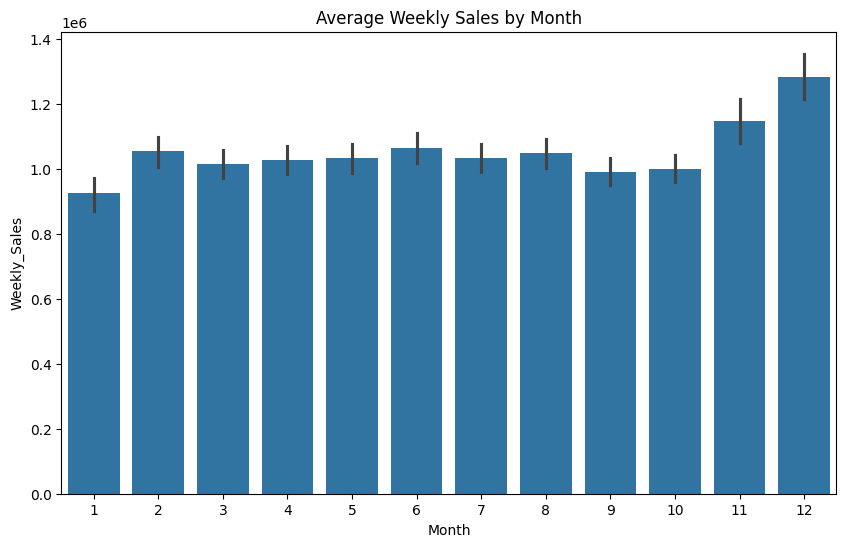

In [ ]:
df['Month'] = df['Date'].dt.month

plt.figure(figsize=(10,6))
sns.barplot(x='Month', y='Weekly_Sales', data=df)
plt.title('Average Weekly Sales by Month')
plt.show()

#### Average Monthly Sales for First 5 Stores

In [95]:
revenue_breakdown = df.groupby(['Month', 'Store'])['Weekly_Sales'].mean().unstack()
revenue_breakdown_first = revenue_breakdown.iloc[:, :5]

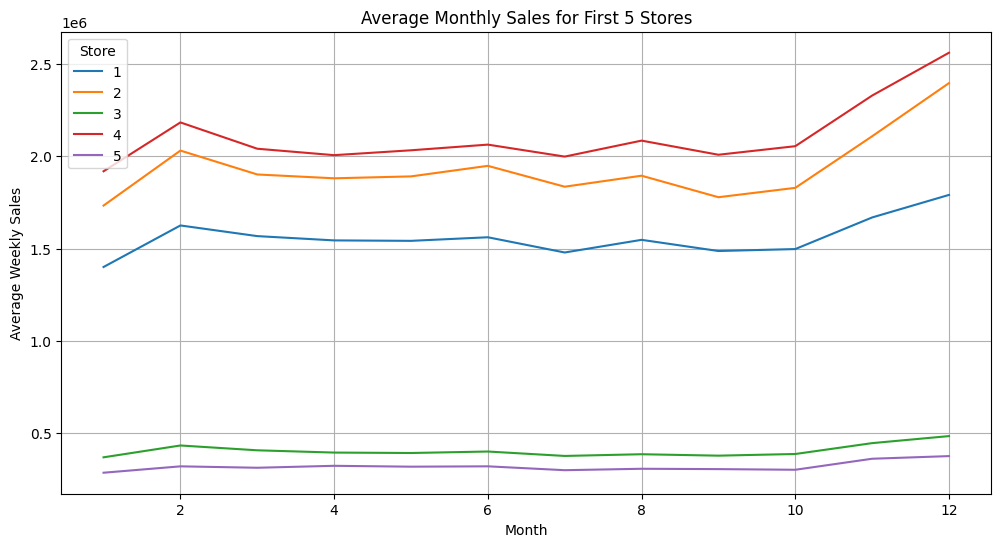

In [96]:
revenue_breakdown_first.plot(figsize=(12,6))
plt.xlabel('Month')
plt.ylabel('Average Weekly Sales')
plt.title('Average Monthly Sales for First 5 Stores')
plt.xticks(rotation=0)
plt.legend(title='Store')
plt.grid(True)
plt.show()

## Thank You 🎀🫶🏻💌